# ArtiFix — 유물 표면 손상 감지 + 유형 분류
## 전체 파이프라인 (최종본 v3)

### 실험 순서
| 실험 | USE_SOBEL | USE_MULTITASK | USE_SYNTHETIC | IN_CHANNELS |
|---|---|---|---|---|
| Baseline | False | False | False | 3 |
| +Synthetic | False | False | True | 3 |
| +Sobel | True | False | True | 4 |
| +Multitask | True | True | True | 4 |

In [1]:
# Cell 1 — 라이브러리 설치 및 임포트
!pip install segmentation-models-pytorch albumentations -q

import os
import cv2
import json
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt

print('PyTorch   :', torch.__version__)
print('GPU       :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '없음')
print('smp       :', smp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
PyTorch   : 2.10.0+cu128
GPU       : Tesla T4
smp       : 0.5.0


In [4]:
# Cell 2 — Config
# ================================================================
# 실험마다 아래 4개만 바꾸세요
# ================================================================
USE_SOBEL     = True  # Baseline/+Synthetic: False | +Sobel/+Multitask: True
USE_MULTITASK = True  # Baseline/+Synthetic/+Sobel: False | +Multitask: True
USE_SYNTHETIC = False  # Baseline: False | 나머지: True | 파인튜닝 시에는 필요 없음
IN_CHANNELS   = 4      # USE_SOBEL=False: 3 | True: 4
# ================================================================

# 설정 mismatch 방지
assert IN_CHANNELS == (4 if USE_SOBEL else 3), \
    f'IN_CHANNELS={IN_CHANNELS}인데 USE_SOBEL={USE_SOBEL}입니다. USE_SOBEL=True면 IN_CHANNELS=4, False면 3이어야 합니다.'

# Multitask + Synthetic 조합 경고
if USE_MULTITASK and not USE_SYNTHETIC:
    print('⚠️  Warning: USE_MULTITASK=True인데 USE_SYNTHETIC=False입니다.')
    print('   CrackDataset 라벨이 [1,0,0]으로 고정되어 classification 학습 효과가 제한됩니다.')

# 경로
CRACK_BASE    = '/kaggle/input/datasets/vangiap/crack500-dataset'
ARTIFACT_DIR  = '/kaggle/input/datasets/bearivh/artifix-artifacts/image'
SYNTHETIC_DIR = '/kaggle/working/synthetic'
WEIGHTS_DIR   = '/kaggle/working/weights'
os.makedirs(SYNTHETIC_DIR + '/images', exist_ok=True)
os.makedirs(SYNTHETIC_DIR + '/masks',  exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

TRAIN_IMG_DIR  = CRACK_BASE + '/train/images'
TRAIN_MASK_DIR = CRACK_BASE + '/train/masks'
VAL_IMG_DIR    = CRACK_BASE + '/val/images'
VAL_MASK_DIR   = CRACK_BASE + '/val/masks'

# 고정값 (절대 바꾸지 않음)
IMAGE_SIZE      = 256
BATCH_SIZE      = 8
NUM_EPOCHS      = 50
LEARNING_RATE   = 3e-4
LAMBDA_CLS      = 0.5
NUM_WORKERS     = 4
PIN_MEMORY      = True
ENCODER_NAME    = 'efficientnet-b2'
ENCODER_WEIGHTS = 'imagenet'
NUM_CLASSES     = 3

print('===== 현재 실험 설정 =====')
print(f'USE_SOBEL     : {USE_SOBEL}')
print(f'USE_MULTITASK : {USE_MULTITASK}')
print(f'USE_SYNTHETIC : {USE_SYNTHETIC}')
print(f'IN_CHANNELS   : {IN_CHANNELS}')
print(f'NUM_EPOCHS    : {NUM_EPOCHS}')
print('설정 검증 통과 ✅')

⚠️  Warning: USE_MULTITASK=True인데 USE_SYNTHETIC=False입니다.
   CrackDataset 라벨이 [1,0,0]으로 고정되어 classification 학습 효과가 제한됩니다.
===== 현재 실험 설정 =====
USE_SOBEL     : True
USE_MULTITASK : True
USE_SYNTHETIC : False
IN_CHANNELS   : 4
NUM_EPOCHS    : 50
설정 검증 통과 ✅


In [5]:
# Cell 3 — Augmentation (모든 실험 공통)
def get_train_transforms():
    mean = [0.485, 0.456, 0.406] + ([0.5] if IN_CHANNELS == 4 else [])
    std  = [0.229, 0.224, 0.225] + ([0.5] if IN_CHANNELS == 4 else [])
    return A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.GaussNoise(p=0.2),
        A.ElasticTransform(p=0.3),
        A.GridDistortion(p=0.3),
        A.CLAHE(p=0.3) if IN_CHANNELS == 3 else A.NoOp(),  # 4채널이면 건너뜀
        A.RandomShadow(p=0.2),
        A.CoarseDropout(p=0.2),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ], is_check_shapes=False)
    
def get_val_transforms():
    mean = [0.485, 0.456, 0.406] + ([0.5] if IN_CHANNELS == 4 else [])
    std  = [0.229, 0.224, 0.225] + ([0.5] if IN_CHANNELS == 4 else [])
    return A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ], is_check_shapes=False)

print('Augmentation 정의 완료')

Augmentation 정의 완료


In [6]:
# Cell 4 — 손상 합성 함수 정의 (항상 실행)
def get_sobel_map(img_gray):
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel   = np.sqrt(sobel_x**2 + sobel_y**2)
    return np.clip(sobel / (sobel.max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def synthesize_crack(img, severity=1.0):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    for _ in range(random.randint(1, 3)):
        x = random.randint(w//4, 3*w//4)
        y = random.randint(h//4, 3*h//4)
        angle = random.uniform(0, 2*np.pi)
        length = random.randint(60, int(150*severity))
        thickness = random.randint(2, 4)
        points = [(x, y)]
        for _ in range(length):
            angle += random.uniform(-0.25, 0.25)
            step = random.uniform(0.8, 1.5)
            nx = int(np.clip(points[-1][0] + step*np.cos(angle), 0, w-1))
            ny = int(np.clip(points[-1][1] + step*np.sin(angle), 0, h-1))
            points.append((nx, ny))
        for j in range(len(points)-1):
            cv2.line(mask, points[j], points[j+1], 255, random.randint(1, thickness))
        if random.random() < 0.5 and len(points) > 15:
            bx, by = random.choice(points[10:])
            ba = angle + random.uniform(0.4, 1.2) * random.choice([-1, 1])
            for _ in range(random.randint(15, 40)):
                ba += random.uniform(-0.2, 0.2)
                bx = int(np.clip(bx + np.cos(ba), 0, w-1))
                by = int(np.clip(by + np.sin(ba), 0, h-1))
                cv2.line(mask, (bx, by), (bx, by), 255, random.randint(1, 2))
    result = img.copy().astype(np.float32)
    result[mask>0, 0] *= 0.20; result[mask>0, 1] *= 0.15; result[mask>0, 2] *= 0.10
    return result.astype(np.uint8), mask

def synthesize_surface_damage(img, severity=1.0):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    for _ in range(random.randint(1, 3)):
        cx = random.randint(w//4, 3*w//4); cy = random.randint(h//4, 3*h//4)
        base_r = random.randint(8, int(25*severity))
        angles = sorted([random.uniform(0, 2*np.pi) for _ in range(random.randint(6, 10))])
        pts = [[int(np.clip(cx + base_r*random.uniform(0.5,1.5)*np.cos(a), 0, w-1)),
                int(np.clip(cy + base_r*random.uniform(0.5,1.5)*np.sin(a), 0, h-1))] for a in angles]
        cv2.fillPoly(mask, [np.array(pts, dtype=np.int32)], 255)
    mask = cv2.GaussianBlur(mask, (5,5), 0)
    mask = (mask > 80).astype(np.uint8) * 255
    result = img.copy()
    result[mask>0] = np.clip(result[mask>0].astype(np.float32)*0.4+120, 0, 255).astype(np.uint8)
    return result, mask

def synthesize_discoloration(img, severity=1.0):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.float32)
    for _ in range(random.randint(1, 3)):
        cx = random.randint(w//4, 3*w//4); cy = random.randint(h//4, 3*h//4)
        base_r = random.randint(12, int(30*severity))
        angles = sorted([random.uniform(0, 2*np.pi) for _ in range(random.randint(8, 14))])
        pts = [[int(np.clip(cx + base_r*random.uniform(0.4,1.6)*np.cos(a), 0, w-1)),
                int(np.clip(cy + base_r*random.uniform(0.4,1.6)*np.sin(a), 0, h-1))] for a in angles]
        temp = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(temp, [np.array(pts, dtype=np.int32)], 255)
        mask = np.clip(mask + temp.astype(np.float32)*random.uniform(0.6, 1.0), 0, 255)
    mask = cv2.GaussianBlur(mask, (41,41), 0)
    mask = (np.clip(mask, 0, 255).astype(np.uint8) > 40).astype(np.uint8) * 255
    result = img.copy().astype(np.float32)
    alpha = (cv2.GaussianBlur(mask, (21,21), 0) / 255.0)[..., np.newaxis] * 0.6
    tint = result.copy()
    if random.random() < 0.5:
        tint[...,0] = np.clip(tint[...,0]*1.2, 0,255); tint[...,1] = np.clip(tint[...,1]*0.95, 0,255); tint[...,2] = np.clip(tint[...,2]*0.6, 0,255)
    else:
        tint[...,0] = np.clip(tint[...,0]*0.7, 0,255); tint[...,1] = np.clip(tint[...,1]*1.1, 0,255); tint[...,2] = np.clip(tint[...,2]*0.8, 0,255)
    return (result*(1-alpha) + tint*alpha).astype(np.uint8), mask

def synthesize_damage(img_path, save_name, damage_types):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.cvtColor(cv2.resize(img, (256,256)), cv2.COLOR_BGR2RGB)
    result = img.copy(); combined_mask = np.zeros((256,256), dtype=np.uint8); cls_label = [0,0,0]
    severity = random.uniform(0.4, 0.9)
    for dtype in damage_types:
        if dtype == 'crack':         result, mask = synthesize_crack(result, severity);         cls_label[0] = 1
        elif dtype == 'surface_damage':     result, mask = synthesize_surface_damage(result, severity);       cls_label[1] = 1
        elif dtype == 'discoloration': result, mask = synthesize_discoloration(result, severity); cls_label[2] = 1
        combined_mask = cv2.bitwise_or(combined_mask, mask)
    cv2.imwrite(f'{SYNTHETIC_DIR}/images/{save_name}.jpg', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f'{SYNTHETIC_DIR}/masks/{save_name}.png',  combined_mask)
    return cls_label

print('합성 함수 정의 완료')

합성 함수 정의 완료


In [ ]:
# Cell 5 — 합성 데이터 생성 (USE_SYNTHETIC=True일 때만 실행)
if USE_SYNTHETIC:
    # 이미 생성된 경우 건너뜀
    existing = len(os.listdir(f'{SYNTHETIC_DIR}/images'))
    if existing >= 1000:
        print(f'합성 데이터 이미 존재 ({existing}개) — 생성 건너뜀')
        with open(f'{SYNTHETIC_DIR}/labels.json', 'r') as f:
            labels_dict = json.load(f)
        print(f'Train: {len(labels_dict["train"])}개 | Val: {len(labels_dict["val"])}개')
    else:
        artifact_imgs = sorted([
            f for f in os.listdir(ARTIFACT_DIR)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])
        print(f'유물 이미지: {len(artifact_imgs)}개')

        # 원본 이미지 기준 Train/Val 분리 (leakage 방지)
        random.seed(42)
        random.shuffle(artifact_imgs)
        train_artifacts = artifact_imgs[:80]
        val_artifacts   = artifact_imgs[80:]

        damage_configs = [
            ['crack'], ['surface_damage'], ['discoloration'],
            ['crack', 'surface_damage'], ['crack', 'discoloration'], ['surface_damage', 'discoloration'],
            ['crack'], ['surface_damage'], ['discoloration'],
            ['crack', 'surface_damage'], ['crack', 'discoloration'], ['surface_damage', 'discoloration'],
        ]

        labels_dict = {'train': {}, 'val': {}}
        count = 0

        for config_idx, config in enumerate(damage_configs):
            for img_idx, img_name in enumerate(train_artifacts):
                save_name = f'train_{config_idx:02d}_{img_idx:04d}'
                result = synthesize_damage(os.path.join(ARTIFACT_DIR, img_name), save_name, config)
                if result: labels_dict['train'][save_name] = result; count += 1
            for img_idx, img_name in enumerate(val_artifacts):
                save_name = f'val_{config_idx:02d}_{img_idx:04d}'
                result = synthesize_damage(os.path.join(ARTIFACT_DIR, img_name), save_name, config)
                if result: labels_dict['val'][save_name] = result; count += 1
            print(f'[{config_idx+1:02d}/12] {config} 완료 — 누적 {count}개')

        with open(f'{SYNTHETIC_DIR}/labels.json', 'w') as f:
            json.dump(labels_dict, f)

        print(f'\n✅ 합성 완료 — Train: {len(labels_dict["train"])}개 | Val: {len(labels_dict["val"])}개')
else:
    print('USE_SYNTHETIC=False — 합성 데이터 생성을 건너뜁니다.')
    labels_dict = None

In [ ]:
# Cell 6 — Dataset 클래스
class CrackDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir; self.mask_dir = mask_dir; self.transform = transform
        self.img_names = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))])
        print(f'CrackDataset: {len(self.img_names)}개')

    def __len__(self): return len(self.img_names)

    def __getitem__(self, idx):
        fname   = self.img_names[idx]
        img_bgr = cv2.imread(os.path.join(self.img_dir, fname))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mask    = (cv2.imread(os.path.join(self.mask_dir, fname), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        image   = np.dstack([img_rgb, get_sobel_map(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))]) if USE_SOBEL else img_rgb
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug['image']; mask = aug['mask'].unsqueeze(0)
        return image, mask, torch.tensor([1.0, 0.0, 0.0], dtype=torch.float32)


class SyntheticDataset(Dataset):
    def __init__(self, synthetic_dir, split='train', transform=None):
        self.img_dir = f'{synthetic_dir}/images'
        self.mask_dir = f'{synthetic_dir}/masks'
        self.transform = transform
        with open(f'{synthetic_dir}/labels.json', 'r') as f:
            all_labels = json.load(f)
        self.labels = all_labels[split]
        self.names = sorted(self.labels.keys())
        print(f'SyntheticDataset ({split}): {len(self.names)}개')

    def __len__(self): return len(self.names)

    def __getitem__(self, idx):
        name    = self.names[idx]
        img_bgr = cv2.imread(os.path.join(self.img_dir, f'{name}.jpg'))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mask    = (cv2.imread(os.path.join(self.mask_dir, f'{name}.png'), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        image   = np.dstack([img_rgb, get_sobel_map(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY))]) if USE_SOBEL else img_rgb
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug['image']; mask = aug['mask'].unsqueeze(0)
        return image, mask, torch.tensor(self.labels[name], dtype=torch.float32)

print('Dataset 클래스 정의 완료')

In [ ]:
# Cell 7 — DataLoader
crack_train_ds = CrackDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, get_train_transforms())
crack_val_ds   = CrackDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   get_val_transforms())

if USE_SYNTHETIC:
    syn_train_ds = SyntheticDataset(SYNTHETIC_DIR, split='train', transform=get_train_transforms())
    syn_val_ds   = SyntheticDataset(SYNTHETIC_DIR, split='val',   transform=get_val_transforms())
    train_ds = ConcatDataset([crack_train_ds, syn_train_ds])
    val_ds   = ConcatDataset([crack_val_ds,   syn_val_ds])
else:
    train_ds = crack_train_ds
    val_ds   = crack_val_ds

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

images, masks, labels = next(iter(train_loader))
print('=== DataLoader ===')
print(f'Train: {len(train_ds)}개 ({len(train_loader)} 배치)')
print(f'Val  : {len(val_ds)}개 ({len(val_loader)} 배치)')
print(f'이미지: {images.shape} | 마스크: {masks.shape} | 라벨: {labels.shape}')

In [9]:
pos_weight = 18.2
print(f'pos_weight: {pos_weight}')

pos_weight: 18.2


In [7]:
# Cell 9 — 모델
class ArtiFix(nn.Module):
    def __init__(self, encoder_name, encoder_weights, in_channels, num_classes):
        super().__init__()
        self.unet = smp.Unet(
            encoder_name=encoder_name, encoder_weights=encoder_weights,
            in_channels=in_channels, classes=1, activation=None,
        )
        bottleneck_ch = self.unet.encoder.out_channels[-1]
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(bottleneck_ch, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        ) if USE_MULTITASK else None

    def forward(self, x):
        features    = self.unet.encoder(x)
        decoder_out = self.unet.decoder(features)
        seg_out     = self.unet.segmentation_head(decoder_out)
        cls_out     = self.cls_head(features[-1]) if (USE_MULTITASK and self.cls_head) else None
        return seg_out, cls_out

model = ArtiFix(ENCODER_NAME, ENCODER_WEIGHTS, IN_CHANNELS, NUM_CLASSES).cuda()
dummy = torch.randn(2, IN_CHANNELS, IMAGE_SIZE, IMAGE_SIZE).cuda()
seg_out, cls_out = model(dummy)
print(f'Seg: {seg_out.shape} | Cls: {cls_out.shape if cls_out is not None else None}')
print(f'파라미터: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Seg: torch.Size([2, 1, 256, 256]) | Cls: torch.Size([2, 3])
파라미터: 10,092,150


In [11]:
# Cell 10 — Loss 함수
class DiceLoss(nn.Module):
    def forward(self, pred, target, smooth=1.0):
        pred = torch.sigmoid(pred).view(-1); target = target.view(-1)
        return 1 - (2*(pred*target).sum() + smooth) / (pred.sum() + target.sum() + smooth)

class SegLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).cuda())
    def forward(self, pred, target):
        return self.dice(pred, target) + self.bce(pred, target)

class TotalLoss(nn.Module):
    def __init__(self, pos_weight, lambda_cls=0.5):
        super().__init__()
        self.seg_loss = SegLoss(pos_weight)
        self.cls_loss = nn.BCEWithLogitsLoss()
        self.lambda_cls = lambda_cls
    def forward(self, seg_pred, seg_target, cls_pred=None, cls_target=None):
        loss = self.seg_loss(seg_pred, seg_target)
        if USE_MULTITASK and cls_pred is not None and cls_target is not None:
            loss = loss + self.lambda_cls * self.cls_loss(cls_pred, cls_target)
        return loss

criterion = TotalLoss(pos_weight=pos_weight, lambda_cls=LAMBDA_CLS)
print(f'Loss 정의 완료 (pos_weight={pos_weight:.1f})')

Loss 정의 완료 (pos_weight=18.2)


In [ ]:
# Cell 11 — 학습 루프 (Mixed Precision)

def dice_coefficient(pred, target, threshold=0.5, smooth=1.0):
    pred = (torch.sigmoid(pred) > threshold).float().view(-1)
    target = target.view(-1)
    return ((2 * (pred * target).sum() + smooth) / 
            (pred.sum() + target.sum() + smooth)).item()

def miou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred = (torch.sigmoid(pred) > threshold).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()

def f1_multilabel_from_probs(probs, target, threshold=0.6):
    pred = (probs > threshold).float()
    tp = (pred * target).sum(dim=0)
    fp = (pred * (1 - target)).sum(dim=0)
    fn = ((1 - pred) * target).sum(dim=0)
    f1_per_class = 2 * tp / (2 * tp + fp + fn + 1e-6)
    return f1_per_class.mean().item()

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = GradScaler()

best_miou = 0.0
train_log = []

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss = 0.0

    for images, masks, labels in train_loader:
        images = images.cuda()
        masks = masks.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()

        with autocast():
            seg_out, cls_out = model(images)
            loss = criterion(seg_out, masks, cls_out, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_miou = 0.0

    all_cls_probs = []
    all_cls_labels = []

    with torch.no_grad():
        for images, masks, labels in val_loader:
            
            images = images.cuda()
            masks = masks.cuda()
            labels = labels.cuda()

            with autocast():
                seg_out, cls_out = model(images)
                loss = criterion(seg_out, masks, cls_out, labels)

            val_loss += loss.item()
            val_dice += dice_coefficient(seg_out, masks)
            val_miou += miou_score(seg_out, masks)

            if USE_MULTITASK and cls_out is not None:
                all_cls_probs.append(torch.sigmoid(cls_out).detach().cpu())
                all_cls_labels.append(labels.detach().cpu())

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_miou /= len(val_loader)

    if USE_MULTITASK and len(all_cls_probs) > 0:
        all_cls_probs  = torch.cat(all_cls_probs,  dim=0)
        all_cls_labels = torch.cat(all_cls_labels, dim=0)

        if epoch == 0:
            print(f'  [디버그] surface_damage 포함: {(all_cls_labels[:,1]==1).sum().item()}')
            print(f'  [디버그] discoloration 포함:  {(all_cls_labels[:,2]==1).sum().item()}')
            print(f'  [디버그] 전체 val 수: {len(all_cls_labels)}')

        val_f1 = f1_multilabel_from_probs(all_cls_probs, all_cls_labels, threshold=0.6)
    else:
        val_f1 = 0.0

    scheduler.step()

    train_log.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_miou': val_miou,
        'val_dice': val_dice,
        'val_f1': val_f1
    })

    print(f'[{epoch+1:02d}/{NUM_EPOCHS}] '
          f'train: {train_loss:.4f} | val: {val_loss:.4f} | '
          f'mIoU: {val_miou:.4f} | Dice: {val_dice:.4f} | F1: {val_f1:.4f}')

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_miou': best_miou,
        }, f'{WEIGHTS_DIR}/best_model.pt')
        print(f'  ✅ Best saved (mIoU: {best_miou:.4f})')

print(f'\n🏁 완료 — Best mIoU: {best_miou:.4f}')

In [ ]:
# Cell 12 — 체크포인트 백업
# 실험 끝날 때마다 ABLATION_NAME만 바꿔서 실행
ABLATION_NAME = 'multitask'  # baseline | synthetic | sobel | multitask

shutil.copy(f'{WEIGHTS_DIR}/best_model.pt', f'{WEIGHTS_DIR}/{ABLATION_NAME}.pt')
print(f'✅ {ABLATION_NAME}.pt 저장 완료')
print(os.listdir(WEIGHTS_DIR))

In [ ]:
# Cell 13 — 결과 시각화 (원본 / GT Mask / Pred Mask / Overlay)
checkpoint = torch.load(f'{WEIGHTS_DIR}/best_model.pt')
model.load_state_dict(checkpoint['model_state'])
model.eval()

sample_images, sample_masks, sample_labels = next(iter(val_loader))
sample_images_cuda = sample_images.cuda()

with torch.no_grad():
    with autocast():
        seg_preds, cls_preds = model(sample_images_cuda)

seg_preds = (torch.sigmoid(seg_preds) > 0.5).float().cpu()

n = 4
fig, axes = plt.subplots(4, n, figsize=(4*n, 14))

for i in range(n):
    img = sample_images[i].cpu()[:3].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    gt_mask   = sample_masks[i, 0].numpy()
    pred_mask = seg_preds[i, 0].numpy()

    overlay = img.copy()
    overlay[pred_mask > 0] = [1, 0, 0]  # 빨강: 예측
    overlay[gt_mask > 0]   = [0, 1, 0]  # 초록: GT
    blended = img * 0.6 + overlay * 0.4

    label = sample_labels[i].numpy()
    label_str = f'C:{int(label[0])} P:{int(label[1])} D:{int(label[2])}'
    sample_miou = miou_score(seg_preds[i:i+1], sample_masks[i:i+1])

    axes[0,i].imshow(img);              axes[0,i].set_title(f'Original\n{label_str}');           axes[0,i].axis('off')
    axes[1,i].imshow(gt_mask, cmap='gray'); axes[1,i].set_title('GT Mask');                     axes[1,i].axis('off')
    axes[2,i].imshow(pred_mask, cmap='gray'); axes[2,i].set_title(f'Pred Mask\nmIoU:{sample_miou:.3f}'); axes[2,i].axis('off')
    axes[3,i].imshow(blended);          axes[3,i].set_title('Overlay\nRed=Pred / Green=GT');    axes[3,i].axis('off')

plt.suptitle(f'ArtiFix Results — Best mIoU: {best_miou:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14 — 학습 곡선 시각화
epochs_list = [log['epoch']      for log in train_log]
train_losses = [log['train_loss'] for log in train_log]
val_losses   = [log['val_loss']   for log in train_log]
val_mious    = [log['val_miou']   for log in train_log]
val_dices    = [log['val_dice']   for log in train_log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_list, train_losses, label='Train Loss')
axes[0].plot(epochs_list, val_losses,   label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_list, val_mious, label='Val mIoU')
axes[1].plot(epochs_list, val_dices, label='Val Dice')
axes[1].axhline(y=best_miou, color='r', linestyle='--', label=f'Best mIoU={best_miou:.4f}')
axes[1].set_title('Metric Curve'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Cell A — 경로 설정
REAL_IMG_DIR  = '/kaggle/input/datasets/bearivh/real-dataset/real_dataset/real_images'
REAL_MASK_DIR = '/kaggle/input/datasets/bearivh/real-dataset/real_dataset/real_masks'

print(os.listdir(REAL_IMG_DIR)[:5])
print(os.listdir(REAL_MASK_DIR)[:5])

['img42.jpg', 'img16.jpg', 'img33.jpg', 'img9.jpg', 'img21.jpg']
['img25.png', 'img7.png', 'img11.png', 'img44.png', 'img45.png']


In [13]:
# Cell B — auto_crop_artifact_v2 함수 정의
def auto_crop_artifact_v2(img_bgr, padding_ratio=0.08, min_area_ratio=0.01):
    if img_bgr is None:
        raise ValueError("img_bgr is None")
    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w      = img_rgb.shape[:2]
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, otsu_bg  = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    otsu_fg     = cv2.bitwise_not(otsu_bg)
    adaptive_fg = cv2.adaptiveThreshold(gray_blur, 255,
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 5)
    artifact_mask = cv2.bitwise_or(otsu_fg, adaptive_fg)
    artifact_mask = cv2.morphologyEx(artifact_mask, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8))
    artifact_mask = cv2.morphologyEx(artifact_mask, cv2.MORPH_OPEN,  np.ones((5,5), np.uint8))
    contours, _ = cv2.findContours(artifact_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_rgb, (0, 0, w, h), artifact_mask
    min_area = h * w * min_area_ratio
    contours = [c for c in contours if cv2.contourArea(c) >= min_area]
    if not contours:
        return img_rgb, (0, 0, w, h), artifact_mask
    largest      = max(contours, key=cv2.contourArea)
    x, y, bw, bh = cv2.boundingRect(largest)
    pad = int(max(bw, bh) * padding_ratio)
    x1  = max(0, x - pad);  y1 = max(0, y - pad)
    x2  = min(w, x+bw+pad); y2 = min(h, y+bh+pad)
    return img_rgb[y1:y2, x1:x2], (x1, y1, x2, y2), artifact_mask

print('auto_crop_artifact_v2 정의 완료')

auto_crop_artifact_v2 정의 완료


RealArtifactDataset: 45개


/tmp/ipykernel_57/3005652591.py:80: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3005652591.py:80: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3005652591.py:80: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3005652591.py:80: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3005652591.py:80: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44

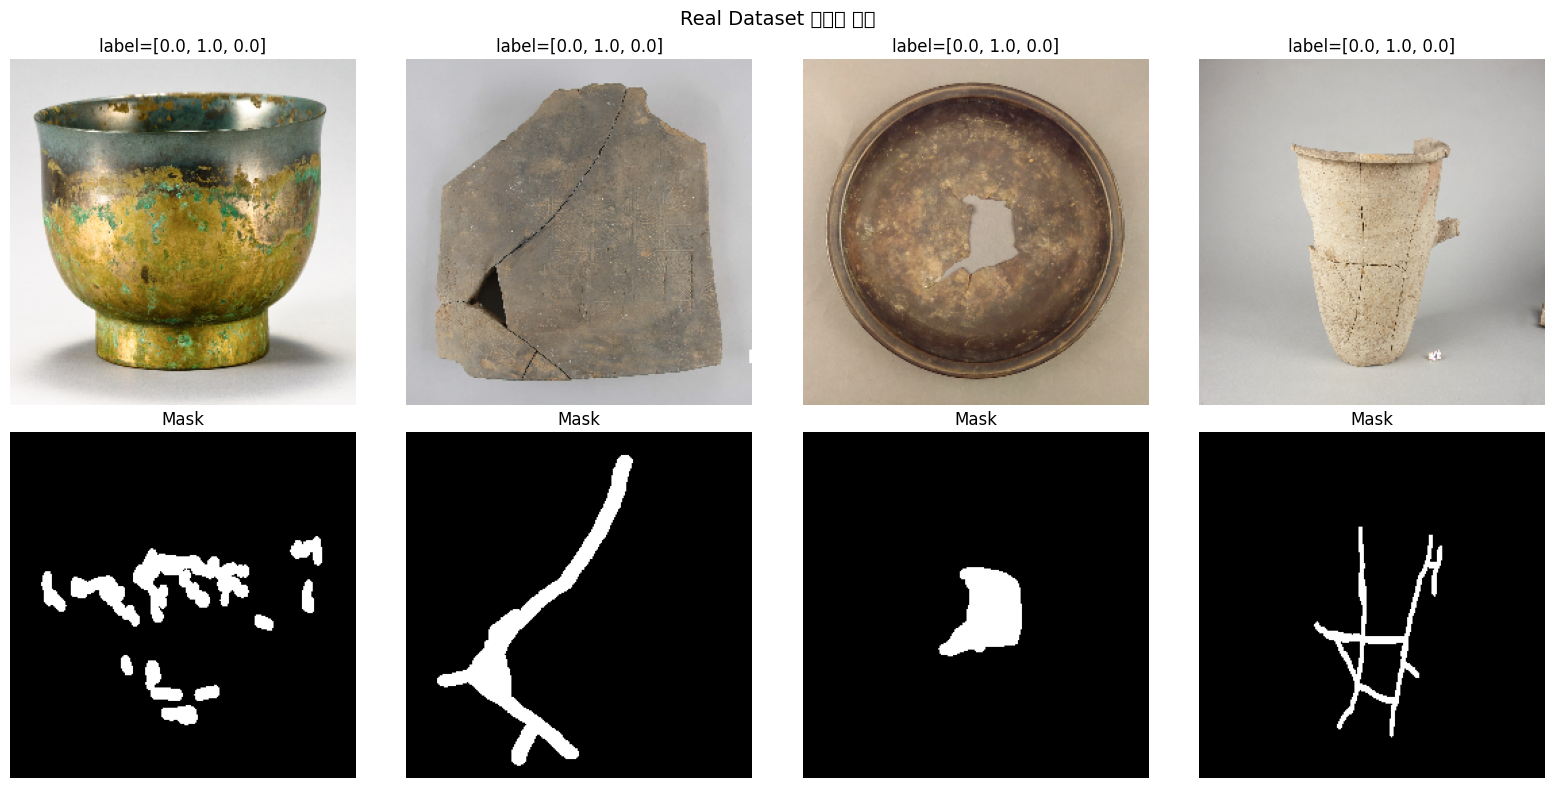

In [14]:
# Cell C — RealArtifactDataset + 시각화 확인
from albumentations.pytorch import ToTensorV2

viz_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2(),
], is_check_shapes=False)

class RealArtifactDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        img_names = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])
        valid_names = []
        for img_name in img_names:
            mask_name = os.path.splitext(img_name)[0] + '.png'
            if os.path.exists(os.path.join(mask_dir, mask_name)):
                valid_names.append(img_name)
        self.img_names = valid_names
        print(f'RealArtifactDataset: {len(self.img_names)}개')

    def __len__(self): return len(self.img_names)

    def __getitem__(self, idx):
        img_name  = self.img_names[idx]
        mask_name = os.path.splitext(img_name)[0] + '.png'
        img_bgr   = cv2.imread(os.path.join(self.img_dir, img_name))
        mask      = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        if img_bgr is None:
            raise FileNotFoundError(os.path.join(self.img_dir, img_name))
        if mask is None:
            raise FileNotFoundError(os.path.join(self.mask_dir, mask_name))
        h_img, w_img = img_bgr.shape[:2]
        if mask.shape[:2] != (h_img, w_img):
            mask = cv2.resize(mask, (w_img, h_img), interpolation=cv2.INTER_NEAREST)
        cropped_rgb, bbox, _ = auto_crop_artifact_v2(img_bgr)
        x1, y1, x2, y2 = bbox
        mask = mask[y1:y2, x1:x2]
        mask = (mask > 127).astype(np.float32)
        if USE_SOBEL:
            cropped_bgr = cv2.cvtColor(cropped_rgb, cv2.COLOR_RGB2BGR)
            gray  = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2GRAY)
            image = np.dstack([cropped_rgb, get_sobel_map(gray)])
        else:
            image = cropped_rgb
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        else:
            image = torch.from_numpy(image.astype(np.float32) / 255.0).permute(2, 0, 1).float()
            mask  = torch.from_numpy(mask).unsqueeze(0).float()
        has_damage = 1.0 if mask.sum() > 0 else 0.0
        cls_label  = torch.tensor([0.0, has_damage, 0.0], dtype=torch.float32)
        return image, mask.float(), cls_label

# 시각화 확인
real_ds_check = RealArtifactDataset(REAL_IMG_DIR, REAL_MASK_DIR, transform=viz_transform)
images_check, masks_check, labels_check = next(iter(DataLoader(
    real_ds_check, batch_size=4, shuffle=True, num_workers=0
)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_vis = images_check[i][:3].permute(1, 2, 0).numpy().astype(np.float32)
    img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-6)
    axes[0, i].imshow(img_vis)
    axes[0, i].set_title(f'label={labels_check[i].tolist()}')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks_check[i][0].numpy(), cmap='gray')
    axes[1, i].set_title('Mask')
    axes[1, i].axis('off')
plt.suptitle('Real Dataset 시각화 확인', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Cell D — Fine-tuning
import torch.nn as nn

DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
FINETUNE_EPOCHS = 10
FINETUNE_LR     = 1e-5

ft_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406, 0.5],
        std=[0.229, 0.224, 0.225, 0.5]
    ),
    ToTensorV2(),
], is_check_shapes=False)

real_ds     = RealArtifactDataset(REAL_IMG_DIR, REAL_MASK_DIR, transform=ft_transform)
real_loader = DataLoader(real_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
print(f'Real DataLoader: {len(real_ds)}개 / {len(real_loader)} 배치')

dice_loss_fn = DiceLoss()
bce_loss_fn  = nn.BCEWithLogitsLoss()

def ft_seg_loss(pred, target):
    return dice_loss_fn(pred, target) + bce_loss_fn(pred, target)

# best model 로드
checkpoint = torch.load(
    '/kaggle/input/datasets/bearivh/artifix-weights/best_model.pt',
    map_location=DEVICE
)
model.load_state_dict(checkpoint['model_state'])
model = model.to(DEVICE)
print(f'Best model 로드 완료 (mIoU: {checkpoint["best_miou"]:.4f})')

ft_optimizer = AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
ft_scheduler = CosineAnnealingLR(ft_optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-7)
ft_scaler    = torch.amp.GradScaler('cuda')
best_ft_loss = float('inf')

for epoch in range(FINETUNE_EPOCHS):
    model.train()
    train_loss = 0.0
    for images, masks, labels in real_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        ft_optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            seg_out, _ = model(images)
            loss = ft_seg_loss(seg_out, masks)
        ft_scaler.scale(loss).backward()
        ft_scaler.step(ft_optimizer)
        ft_scaler.update()
        train_loss += loss.item()
    train_loss /= len(real_loader)
    ft_scheduler.step()

    print(f'[FT {epoch+1:02d}/{FINETUNE_EPOCHS}] seg_loss: {train_loss:.4f}')

    if train_loss < best_ft_loss:
        best_ft_loss = train_loss
        torch.save({
            'epoch':        epoch + 1,
            'model_state':  model.state_dict(),
            'optimizer':    ft_optimizer.state_dict(),
            'best_ft_loss': best_ft_loss,
        }, f'{WEIGHTS_DIR}/best_finetuned.pt')
        print(f'  ✅ Best fine-tuned saved (loss: {best_ft_loss:.4f})')

print(f'\n🏁 Fine-tuning 완료 — Best loss: {best_ft_loss:.4f}')

RealArtifactDataset: 45개
Real DataLoader: 45개 / 12 배치
Best model 로드 완료 (mIoU: 0.6764)
[FT 01/10] seg_loss: 1.1918
  ✅ Best fine-tuned saved (loss: 1.1918)
[FT 02/10] seg_loss: 1.0552
  ✅ Best fine-tuned saved (loss: 1.0552)
[FT 03/10] seg_loss: 1.0945
[FT 04/10] seg_loss: 0.9887
  ✅ Best fine-tuned saved (loss: 0.9887)
[FT 05/10] seg_loss: 1.0419
[FT 06/10] seg_loss: 0.9792
  ✅ Best fine-tuned saved (loss: 0.9792)
[FT 07/10] seg_loss: 1.0168
[FT 08/10] seg_loss: 0.9777
  ✅ Best fine-tuned saved (loss: 0.9777)
[FT 09/10] seg_loss: 0.9912
[FT 10/10] seg_loss: 0.9806

🏁 Fine-tuning 완료 — Best loss: 0.9777
